# Análise Exploratória do Catálogo Disney+ – Filmes e Séries

Este projeto faz parte do meu portfólio como estudante de Análise de Dados e tem como objetivo aplicar conceitos fundamentais de análise exploratória em um dataset público contendo os títulos disponíveis na plataforma Disney+.

O dataset contém informações sobre filmes e séries, incluindo título, tipo, classificação indicativa, país de origem, data de lançamento e data de adição à plataforma.

### 📌 Objetivos:

- Entender a distribuição de conteúdos entre filmes e séries.
- Verificar as classificações indicativas mais comuns.
- Identificar os países com maior presença no catálogo.
- Observar os padrões de lançamento ao longo dos anos.
- Gerar visualizações simples e informativas com a biblioteca Seaborn.

A análise foi realizada com a biblioteca `pandas` para manipulação de dados e `seaborn`/`matplotlib` para visualização. Todas as etapas foram desenvolvidas com foco didático para consolidar conhecimentos iniciais em Análise de Dados.


# Requisitos

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Exibir os gráficos dentro do notebook
%matplotlib inline

# Estilo visual do seaborn
sns.set(style="whitegrid")

# 1- Carregando e Visualizando os Dados

In [2]:
df = pd.read_csv('/kaggle/input/disney-movies-and-tv-shows/disney_plus_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Duck the Halls: A Mickey Mouse Christmas Special,"Alonso Ramirez Ramos, Dave Wasson","Chris Diamantopoulos, Tony Anselmo, Tress MacN...",NaN,"November 26, 2021",2016,TV-G,23 min,"Animation, Family",Join Mickey and the gang as they duck the halls!
1,s2,Movie,Ernest Saves Christmas,John Cherry,"Jim Varney, Noelle Parker, Douglas Seale",NaN,"November 26, 2021",1988,PG,91 min,Comedy,Santa Claus passes his magic bag to a new St. ...
2,s3,Movie,Ice Age: A Mammoth Christmas,Karen Disher,"Raymond Albert Romano, John Leguizamo, Denis L...",United States,"November 26, 2021",2011,TV-G,23 min,"Animation, Comedy, Family",Sid the Sloth is on Santa's naughty list.
3,s4,Movie,The Queen Family Singalong,Hamish Hamilton,"Darren Criss, Adam Lambert, Derek Hough, Alexa...",NaN,"November 26, 2021",2021,TV-PG,41 min,Musical,"This is real life, not just fantasy!"
4,s5,TV Show,The Beatles: Get Back,NaN,"John Lennon, Paul McCartney, George Harrison, ...",NaN,"November 25, 2021",2021,NaN,1 Season,"Docuseries, Historical, Music",A three-part documentary from Peter Jackson ca...


# 2- Entendendo a Estrutura e Qualidade dos Dados

In [3]:
# Verificando informações básicas do DataFrame:
# Quantidade de colunas, tipos de dados e valores nulos.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1450 entries, 0 to 1449
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       1450 non-null   object
 1   type          1450 non-null   object
 2   title         1450 non-null   object
 3   director      977 non-null    object
 4   cast          1260 non-null   object
 5   country       1231 non-null   object
 6   date_added    1447 non-null   object
 7   release_year  1450 non-null   int64 
 8   rating        1447 non-null   object
 9   duration      1450 non-null   object
 10  listed_in     1450 non-null   object
 11  description   1450 non-null   object
dtypes: int64(1), object(11)
memory usage: 136.1+ KB


In [4]:
# Exibindo estatísticas descritivas das colunas do dataset,
# para entender a distribuição dos dados (incluindo colunas categóricas).
df.describe(include='all')

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,1450,1450,1450,977,1260,1231,1447,1450.000000,1447,1450,1450,1450
unique,1450,2,1450,609,1193,89,167,NaN,9,158,329,1448
top,s1,Movie,Duck the Halls: A Mickey Mouse Christmas Special,Jack Hannah,Winston Hibler,United States,"November 12, 2019",NaN,TV-G,1 Season,"Animation, Comedy, Family","Cooper and Cami Wrather co-host ""Would You Wra..."
freq,1,1052,1,17,10,1005,722,NaN,318,219,124,2
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003.091724,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.860162,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1928.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,NaN,NaN,NaN,NaN


# 3- Tratamento de Dados Ausentes/Valores Nulos

In [5]:
# Contando valores nulos por coluna
df.isnull().sum()

show_id           0
type              0
title             0
director        473
cast            190
country         219
date_added        3
release_year      0
rating            3
duration          0
listed_in         0
description       0
dtype: int64

In [6]:
# Preenchendo os valores ausentes com categorias genéricas
df['director'] = df['director'].fillna('Desconhecido')
df['cast'] = df['cast'].fillna('Não informado')
df['country'] = df['country'].fillna('Não informado')

# Preenchendo 'rating' com o valor mais frequente (moda)
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

# Removendo registros com data de adição ausente
df = df.dropna(subset=['date_added'])

In [7]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

# 4 - Análise Exploratória com Gráficos:

## O catálogo do Disney+ é mais focado em Filmes ou Séries?

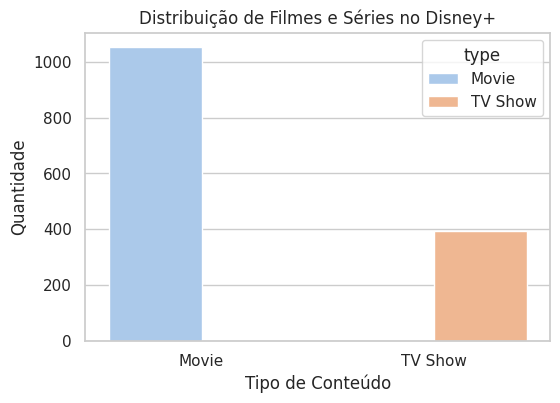

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type', hue='type', palette='pastel')
plt.title('Distribuição de Filmes e Séries no Disney+')
plt.xlabel('Tipo de Conteúdo')
plt.ylabel('Quantidade')
plt.show()


## O conteúdo é mais clássico ou moderno?

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


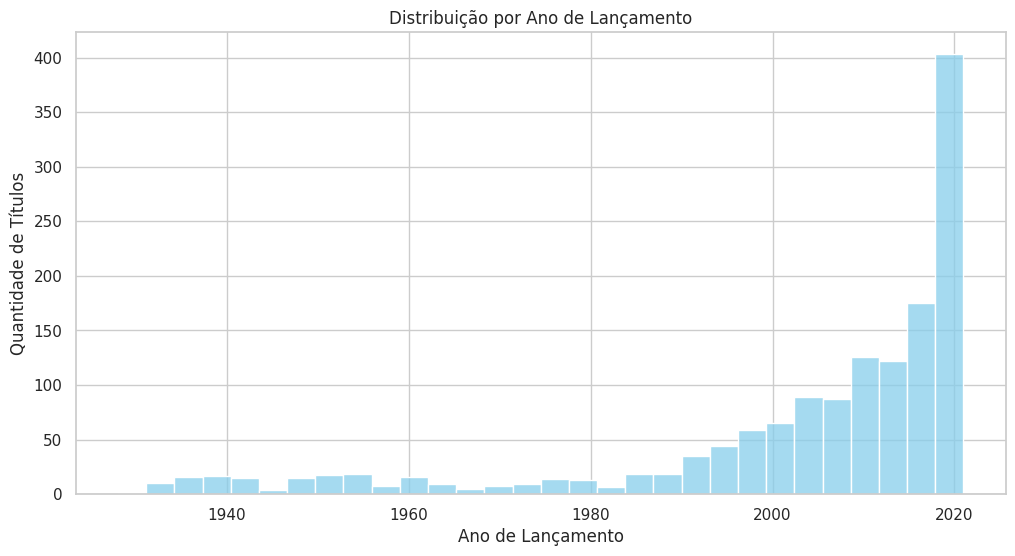

In [9]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='release_year', bins=30, kde=False, color='skyblue')
plt.title('Distribuição por Ano de Lançamento')
plt.xlabel('Ano de Lançamento')
plt.ylabel('Quantidade de Títulos')
plt.show()

## O conteúdo é voltado mais para qual faixa etária?

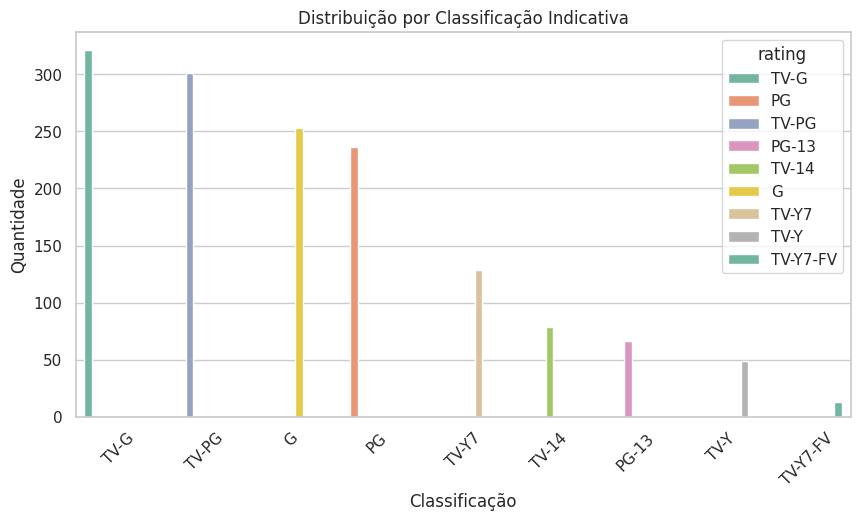

In [10]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x='rating',
    hue='rating',
    order=df['rating'].value_counts().index,
    palette='Set2'
)
plt.title('Distribuição por Classificação Indicativa')
plt.xlabel('Classificação')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.show()


## Top 10 Países com maior número de títulos

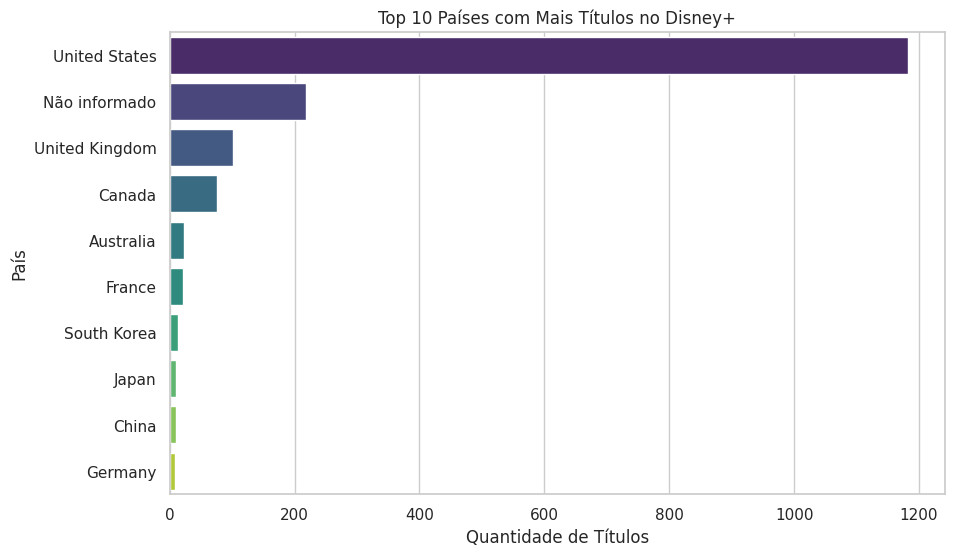

In [11]:
top_countries = (
    df['country']
    .dropna()
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Países com Mais Títulos no Disney+')
plt.xlabel('Quantidade de Títulos')
plt.ylabel('País')
plt.show()

## Quantidade de títulos adicionados por ano:

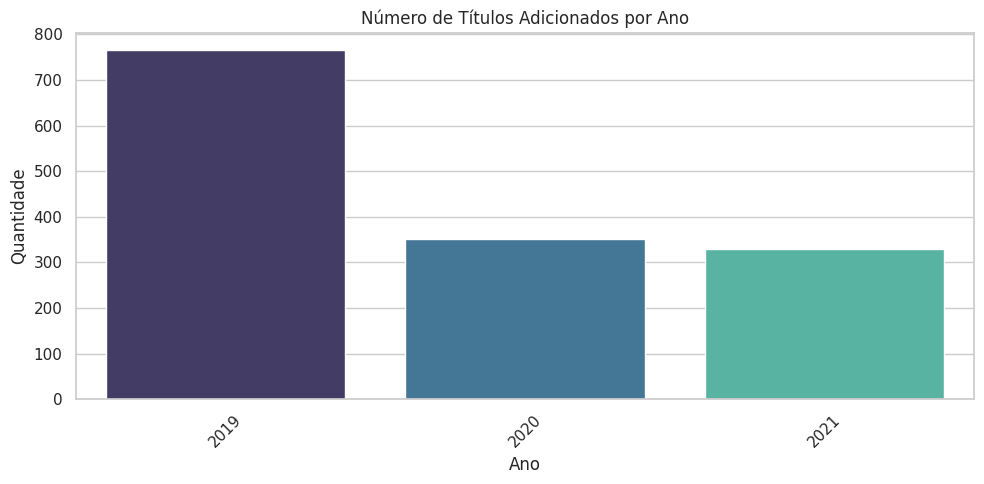

In [12]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Criar a nova coluna com o ano
df['ano_adicionado'] = df['date_added'].dt.year

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='ano_adicionado', palette='mako')
plt.title('Número de Títulos Adicionados por Ano')
plt.xlabel('Ano')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5- Conclusão e Insights

Após a análise dos dados do catálogo Disney+, foi possível extrair os seguintes insights:

🔹 **Distribuição por Tipo**  
Filmes representam a maioria do conteúdo disponível, indicando um foco maior da plataforma nesse formato.

🔹 **Classificação Indicativa**  
A maioria dos títulos possui classificação voltada para o público infantil e familiar, coerente com o posicionamento da Disney como produtora de conteúdo seguro e voltado para todas as idades.

🔹 **Países de Origem**  
Os Estados Unidos dominam o catálogo, o que era esperado devido ao fato da Disney ser uma empresa americana. No entanto, também há diversidade com títulos de países como Canadá, Reino Unido e Austrália.

🔹 **Adições por Ano**  
Houve uma concentração maior de adições ao catálogo nos anos iniciais da plataforma, com destaque para 2019, ano de expansão global do Disney+.

### 💡 Considerações Finais

Este projeto reforçou a importância da limpeza e visualização de dados para gerar conclusões compreensíveis. Como iniciante, foi essencial entender o comportamento do dataset e corrigir avisos (warnings) para garantir compatibilidade futura com bibliotecas atualizadas.

Este notebook será atualizado com novas análises conforme evoluo no aprendizado.

Obrigado por acompanhar!


# Referências
- [Dataset - Disney+ TV Shows and Movies (Kaggle)](https://www.kaggle.com/datasets/shivamb/disney-movies-and-tv-shows)
- Documentação do Pandas e Seaborn
